In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

/tmp/ipykernel_121090/1108342508.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  return y*(1/y-1)
/tmp/ipykernel_121090/1108342508.py:7: RuntimeWarning: invalid value encountered in scalar multiply
  return y*(1/y-1)


Text(0, 0.5, 'R_k/K²')

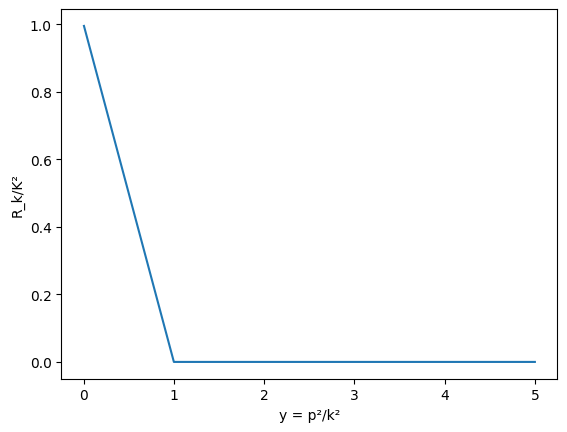

In [2]:
# Litim regulator

def litim(y):
    if 1 < y:
        return 0
    else:
        return y*(1/y-1)
    
y = np.linspace(0,5,1000)
R_vals = np.zeros(1000)

for i in range(len(y)):
    R_vals[i] = litim(y[i])

plt.plot(y, R_vals)
plt.xlabel("y = p²/k²")
plt.ylabel("R_k/K²")

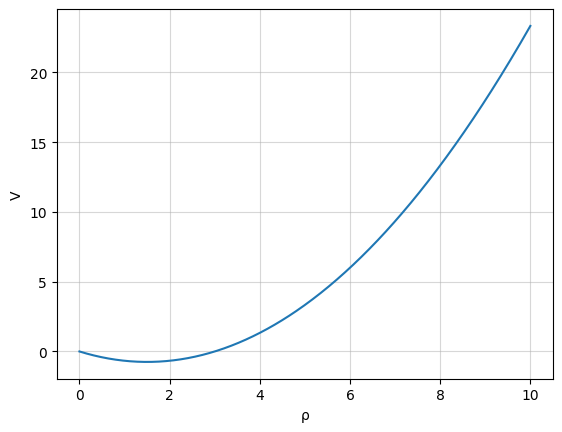

In [3]:
data = np.loadtxt("../results/V_classical.txt", skiprows=1, delimiter=",")

ρ = data[:,0]
V = data[:,1]

plt.plot(ρ,V)
plt.xlabel("ρ")
plt.ylabel("V")
plt.grid(alpha=0.5)

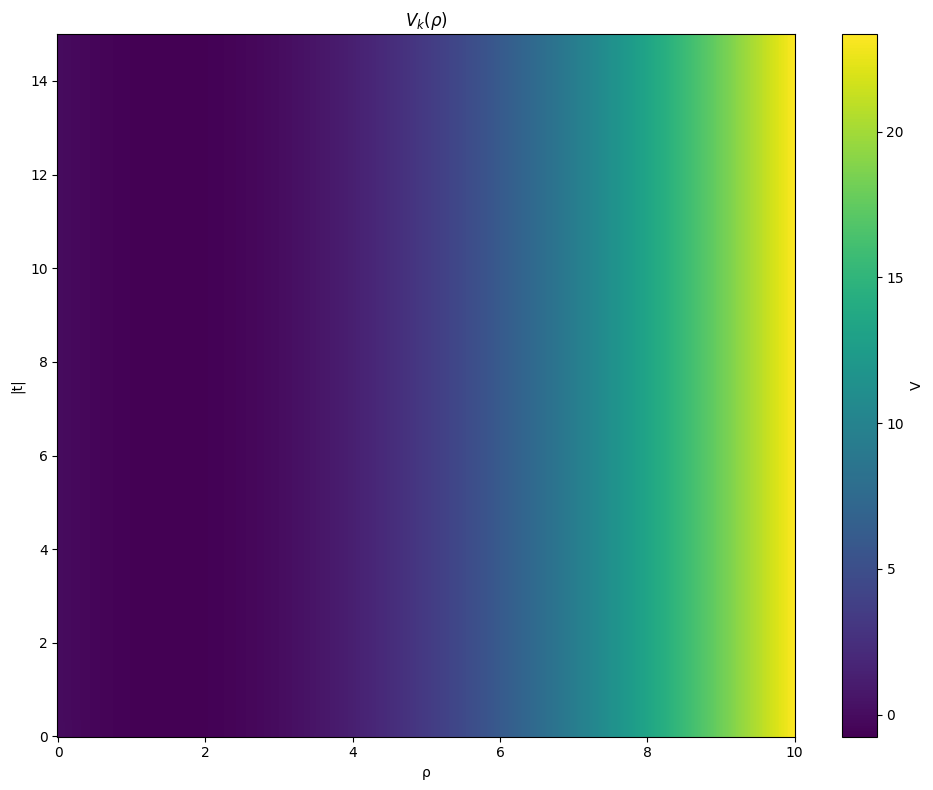

In [4]:
from pathlib import Path

result_dir = Path("../results")

files = sorted(
    [p for p in result_dir.glob("V_*.txt") if p.name != "V_classical.txt"],
    key = lambda p: float(p.stem.split("_")[1])
)

t_values = []
rho_grid = None
V_grid = []

for path in files:
    data = np.loadtxt(path, skiprows=1, delimiter=",")
    rho = data[:,0]
    V = data[:,1]

    if rho_grid is None:
        rho_grid = rho
    elif not np.allclose(rho_grid, rho):
        raise ValueError(f"rho grid mismatch in {path.name}")

    t_values.append(float(path.stem.split("_")[1]))
    V_grid.append(V)

V_grid = np.array(V_grid)
t_values = np.array(t_values)

plt.figure(figsize=(10,8))
mesh = plt.pcolormesh(rho_grid, t_values, V_grid, shading="auto", cmap="viridis")
plt.xlabel("ρ")
plt.ylabel("|t|")
plt.title(rf"$V_k(ρ)$")
plt.colorbar(mesh, label="V")
plt.tight_layout()